In [1]:
# ============================================
# NOTEBOOK 03 - EVALUACION DE MODELOS
# Evaluacion Parcial N°2 - SCY1101
# ============================================
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

from data_preprocessing import dividir_datos
from model_training import (
    entrenar_modelos_clasificacion,
    entrenar_modelos_regresion,
    cargar_modelo,
)
from model_evaluation import (
    evaluar_clasificacion,
    evaluar_regresion,
    validacion_cruzada,
    comparar_modelos,
    graficar_matriz_confusion,
)

sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# ============================================
# CARGA DE DATOS Y PREPARACION
# ============================================
consultas = pd.read_parquet("../data/02_intermediate/consultas_cleaned.parquet")
pacientes = pd.read_parquet("../data/02_intermediate/pacientes_cleaned.parquet")
examenes = pd.read_parquet("../data/02_intermediate/examenes_cleaned.parquet")
medicamentos = pd.read_parquet("../data/02_intermediate/medicamentos_cleaned.parquet")

df = consultas.merge(pacientes, on="id_paciente", how="left")
df = df.merge(examenes, on="id_consulta", how="left")
df = df.merge(medicamentos, on="id_consulta", how="left")

# Features y target
feature_cols = [
    'id_medico', 'resultado', 'duracion_dias', 'costo_unitario',
    'id_examen', 'id_prescripcion'
]

mediana_costo = df['costo'].median()
df['costo_alto'] = (df['costo'] > mediana_costo).astype(int)

X = df[feature_cols].fillna(0)
y = df['costo_alto']
y_reg = df['costo'].fillna(df['costo'].median())

X_train, X_test, y_train, y_test = dividir_datos(X, y)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = dividir_datos(X, y_reg)

# Reentrenar modelos
modelos_clf = entrenar_modelos_clasificacion(X_train, y_train)
modelos_reg = entrenar_modelos_regresion(X_train_reg, y_train_reg)

print(f"\nDatos preparados y modelos entrenados")

 Train: 936 filas | Test: 234 filas
 Train: 936 filas | Test: 234 filas
Entrenando Logistic Regression...
  Logistic Regression entrenado correctamente
Entrenando Decision Tree...
  Decision Tree entrenado correctamente
Entrenando Random Forest...
  Random Forest entrenado correctamente
Entrenando Gradient Boosting...
  Gradient Boosting entrenado correctamente
Entrenando KNN...
  KNN entrenado correctamente
Entrenando SVM...
  SVM entrenado correctamente
Entrenando Naive Bayes...
  Naive Bayes entrenado correctamente
Entrenando Linear Regression...
  Linear Regression entrenado correctamente
Entrenando Ridge Regression...
  Ridge Regression entrenado correctamente
Entrenando Decision Tree Regressor...
  Decision Tree Regressor entrenado correctamente
Entrenando Random Forest Regressor...
  Random Forest Regressor entrenado correctamente
Entrenando KNN Regressor...
  KNN Regressor entrenado correctamente
Entrenando SVR...
  SVR entrenado correctamente

Datos preparados y modelos entren

In [3]:
# ============================================
# VALIDACION CRUZADA - CLASIFICACION
# ============================================
print("Validacion Cruzada - Modelos de Clasificacion (5 folds)")
print("="*55)

resultados_cv_clf = []
for nombre, modelo in modelos_clf.items():
    print(f"\n{nombre}:")
    resultado = validacion_cruzada(modelo, X, y, cv=5, tarea="clasificacion")
    resultados_cv_clf.append({
        "modelo": nombre,
        "cv_media": resultado["media"],
        "cv_std": resultado["std"],
    })

df_cv_clf = pd.DataFrame(resultados_cv_clf).sort_values("cv_media", ascending=False)
print("\nResumen validacion cruzada clasificacion:")
print(df_cv_clf.to_string())

Validacion Cruzada - Modelos de Clasificacion (5 folds)

Logistic Regression:
  CV (f1_weighted): 0.5417 +/- 0.0403

Decision Tree:
  CV (f1_weighted): 0.5597 +/- 0.021

Random Forest:
  CV (f1_weighted): 0.5879 +/- 0.0182

Gradient Boosting:
  CV (f1_weighted): 0.5898 +/- 0.039

KNN:
  CV (f1_weighted): 0.5671 +/- 0.0206

SVM:
  CV (f1_weighted): 0.5646 +/- 0.0103

Naive Bayes:
  CV (f1_weighted): 0.5253 +/- 0.0315

Resumen validacion cruzada clasificacion:
                modelo  cv_media  cv_std
3    Gradient Boosting    0.5898  0.0390
2        Random Forest    0.5879  0.0182
4                  KNN    0.5671  0.0206
5                  SVM    0.5646  0.0103
1        Decision Tree    0.5597  0.0210
0  Logistic Regression    0.5417  0.0403
6          Naive Bayes    0.5253  0.0315


In [4]:
# ============================================
# VALIDACION CRUZADA - REGRESION
# ============================================
print("Validacion Cruzada - Modelos de Regresion (5 folds)")
print("="*55)

resultados_cv_reg = []
for nombre, modelo in modelos_reg.items():
    print(f"\n{nombre}:")
    resultado = validacion_cruzada(modelo, X, y_reg, cv=5, tarea="regresion")
    resultados_cv_reg.append({
        "modelo": nombre,
        "cv_media": resultado["media"],
        "cv_std": resultado["std"],
    })

df_cv_reg = pd.DataFrame(resultados_cv_reg).sort_values("cv_media", ascending=False)
print("\nResumen validacion cruzada regresion:")
print(df_cv_reg.to_string())

Validacion Cruzada - Modelos de Regresion (5 folds)

Linear Regression:
  CV (r2): -0.015 +/- 0.0136

Ridge Regression:
  CV (r2): -0.015 +/- 0.0136

Decision Tree Regressor:
  CV (r2): -0.7082 +/- 0.8276

Random Forest Regressor:
  CV (r2): -0.4938 +/- 0.7675

KNN Regressor:
  CV (r2): -0.5568 +/- 0.7816

SVR:
  CV (r2): -0.0055 +/- 0.0089

Resumen validacion cruzada regresion:
                    modelo  cv_media  cv_std
5                      SVR   -0.0055  0.0089
0        Linear Regression   -0.0150  0.0136
1         Ridge Regression   -0.0150  0.0136
3  Random Forest Regressor   -0.4938  0.7675
4            KNN Regressor   -0.5568  0.7816
2  Decision Tree Regressor   -0.7082  0.8276


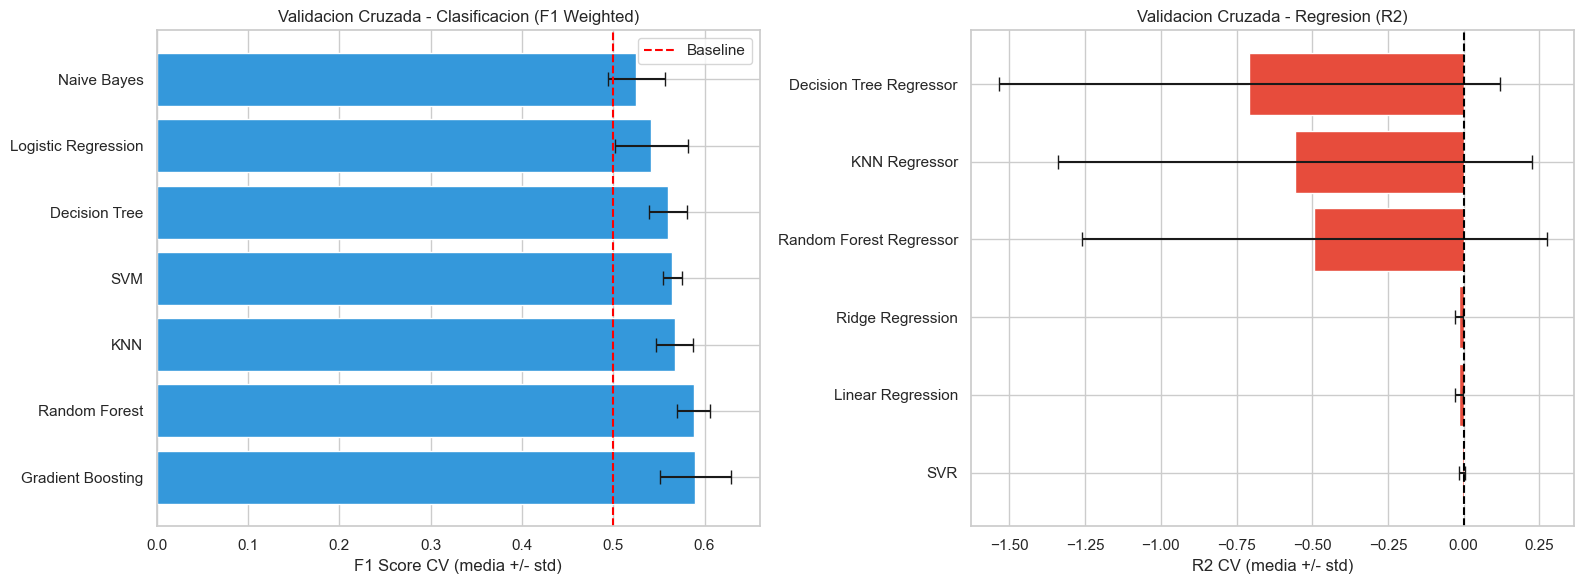

Grafico guardado


In [5]:
# ============================================
# VISUALIZACION VALIDACION CRUZADA
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CV Clasificacion
axes[0].barh(df_cv_clf['modelo'], df_cv_clf['cv_media'], 
             xerr=df_cv_clf['cv_std'], color='#3498db', capsize=5)
axes[0].set_title("Validacion Cruzada - Clasificacion (F1 Weighted)")
axes[0].set_xlabel("F1 Score CV (media +/- std)")
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Baseline')
axes[0].legend()

# CV Regresion
colores = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_cv_reg['cv_media']]
axes[1].barh(df_cv_reg['modelo'], df_cv_reg['cv_media'],
             xerr=df_cv_reg['cv_std'], color=colores, capsize=5)
axes[1].set_title("Validacion Cruzada - Regresion (R2)")
axes[1].set_xlabel("R2 CV (media +/- std)")
axes[1].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig("../src/results/plots/03_validacion_cruzada.png", dpi=150)
plt.show()
print("Grafico guardado")

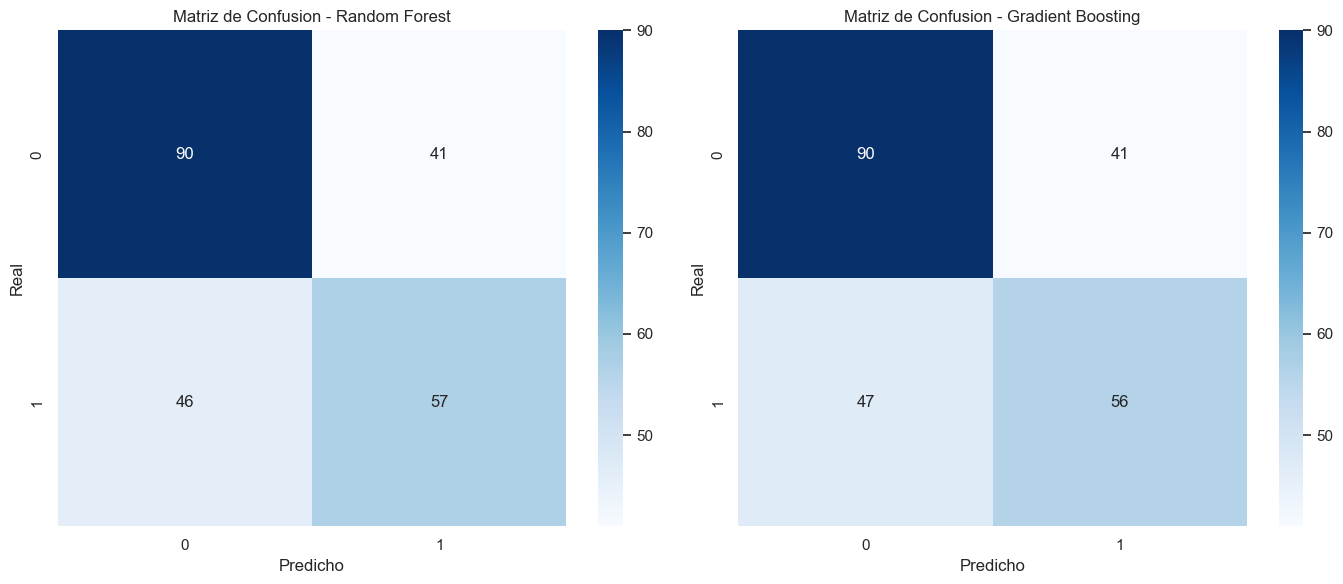

Grafico guardado


In [6]:
# ============================================
# MATRIZ DE CONFUSION - MEJORES MODELOS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, nombre in zip(axes, ["Random Forest", "Gradient Boosting"]):
    modelo = modelos_clf[nombre]
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de Confusion - {nombre}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.savefig("../src/results/plots/03_matrices_confusion.png", dpi=150)
plt.show()
print("Grafico guardado")

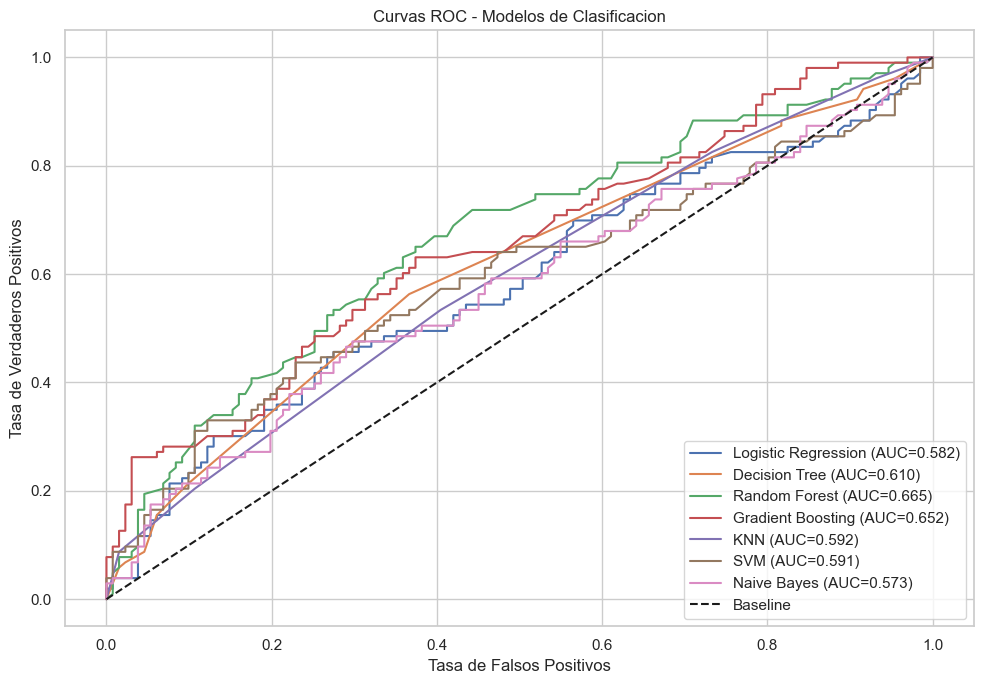

Grafico guardado


In [7]:
# ============================================
# CURVAS ROC - MODELOS DE CLASIFICACION
# ============================================
plt.figure(figsize=(10, 7))

for nombre, modelo in modelos_clf.items():
    try:
        y_prob = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.3f})")
    except Exception:
        pass

plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC - Modelos de Clasificacion")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../src/results/plots/03_curvas_roc.png", dpi=150)
plt.show()
print("Grafico guardado")

In [8]:
# ============================================
# REPORTE FINAL DE CLASIFICACION
# ============================================
print("Reporte de Clasificacion - Random Forest (Mejor Modelo)")
print("="*55)
y_pred_rf = modelos_clf["Random Forest"].predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=["Costo Bajo", "Costo Alto"]))

# Guardar resultados CV
df_cv_clf.to_csv("../src/results/metrics/cv_clasificacion.csv", index=False)
df_cv_reg.to_csv("../src/results/metrics/cv_regresion.csv", index=False)

print("\nArchivos guardados en src/results/metrics/")
print("\nResumen evaluacion:")
print(f"Mejor clasificador (CV): Gradient Boosting - F1={df_cv_clf['cv_media'].max():.4f}")
print(f"Mejor regresor (CV):     SVR - R2={df_cv_reg['cv_media'].max():.4f}")

Reporte de Clasificacion - Random Forest (Mejor Modelo)
              precision    recall  f1-score   support

  Costo Bajo       0.66      0.69      0.67       131
  Costo Alto       0.58      0.55      0.57       103

    accuracy                           0.63       234
   macro avg       0.62      0.62      0.62       234
weighted avg       0.63      0.63      0.63       234


Archivos guardados en src/results/metrics/

Resumen evaluacion:
Mejor clasificador (CV): Gradient Boosting - F1=0.5898
Mejor regresor (CV):     SVR - R2=-0.0055


In [9]:
# ============================================
# ANALISIS OVERFITTING Y UNDERFITTING
# Comparacion Train Score vs Test Score
# ============================================
from sklearn.metrics import f1_score

resultados_overfitting = []

for nombre, modelo in modelos_clf.items():
    # Score en entrenamiento
    y_pred_train = modelo.predict(X_train)
    f1_train = f1_score(y_train, y_pred_train, average="weighted", zero_division=0)

    # Score en prueba
    y_pred_test = modelo.predict(X_test)
    f1_test = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

    diferencia = f1_train - f1_test

    if diferencia > 0.15:
        diagnostico = "Overfitting"
    elif f1_train < 0.6 and f1_test < 0.6:
        diagnostico = "Underfitting"
    else:
        diagnostico = "Bien ajustado"

    resultados_overfitting.append({
        "modelo": nombre,
        "f1_train": round(f1_train, 4),
        "f1_test": round(f1_test, 4),
        "diferencia": round(diferencia, 4),
        "diagnostico": diagnostico,
    })

df_overfitting = pd.DataFrame(resultados_overfitting)
print("Analisis de Overfitting/Underfitting:")
print(df_overfitting.to_string())

Analisis de Overfitting/Underfitting:
                modelo  f1_train  f1_test  diferencia    diagnostico
0  Logistic Regression    0.5513   0.5569     -0.0056   Underfitting
1        Decision Tree    0.6431   0.6031      0.0400  Bien ajustado
2        Random Forest    0.9412   0.6271      0.3142    Overfitting
3    Gradient Boosting    0.7685   0.6225      0.1460  Bien ajustado
4                  KNN    0.7137   0.5693      0.1444  Bien ajustado
5                  SVM    0.6133   0.5973      0.0159  Bien ajustado
6          Naive Bayes    0.5272   0.5837     -0.0565   Underfitting


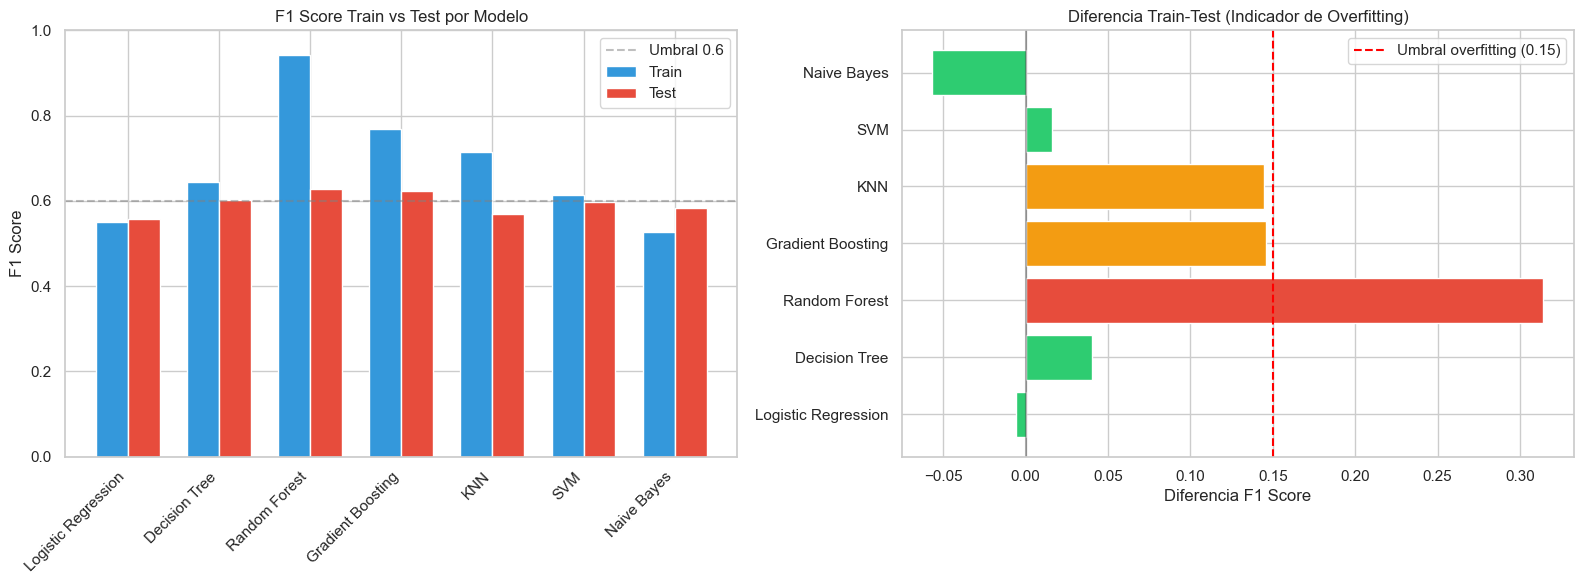


Resumen diagnostico:
                modelo    diagnostico
0  Logistic Regression   Underfitting
1        Decision Tree  Bien ajustado
2        Random Forest    Overfitting
3    Gradient Boosting  Bien ajustado
4                  KNN  Bien ajustado
5                  SVM  Bien ajustado
6          Naive Bayes   Underfitting

Resultados guardados en src/results/metrics/


In [10]:
# ============================================
# VISUALIZACION OVERFITTING/UNDERFITTING
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(df_overfitting))
width = 0.35

# Grafico barras train vs test
axes[0].bar(x - width/2, df_overfitting['f1_train'], width, label='Train', color='#3498db')
axes[0].bar(x + width/2, df_overfitting['f1_test'], width, label='Test', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_overfitting['modelo'], rotation=45, ha='right')
axes[0].set_title("F1 Score Train vs Test por Modelo")
axes[0].set_ylabel("F1 Score")
axes[0].axhline(y=0.6, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.6')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Grafico diferencia
colores = ['#e74c3c' if d > 0.15 else '#f39c12' if d > 0.05 else '#2ecc71'
           for d in df_overfitting['diferencia']]
axes[1].barh(df_overfitting['modelo'], df_overfitting['diferencia'], color=colores)
axes[1].axvline(x=0.15, color='red', linestyle='--', label='Umbral overfitting (0.15)')
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title("Diferencia Train-Test (Indicador de Overfitting)")
axes[1].set_xlabel("Diferencia F1 Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("../src/results/plots/03_overfitting_analysis.png", dpi=150)
plt.show()

# Resumen
print("\nResumen diagnostico:")
print(df_overfitting[['modelo', 'diagnostico']].to_string())
df_overfitting.to_csv("../src/results/metrics/analisis_overfitting.csv", index=False)
print("\nResultados guardados en src/results/metrics/")